# Exercises
---
_Rijcklof Hofman s4792432_

In [214]:
import numpy as np
from scipy import io
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.manifold import Isomap
import matplotlib.pylab as plt
import seaborn as sns
import sys
import os
sys.path.append(os.path.abspath("code"))
from utils import download_data

sns.set_theme(context='notebook',style='white',font_scale=1.5,
              rc = {'axes.spines.top':False,'axes.spines.right':False})

from ipywidgets import interact
import ipywidgets as widgets
from tqdm import tqdm
import pickle
from scipy.stats import sem
from scipy.ndimage import gaussian_filter1d

In [2]:
# download lesson data
download_data('https://surfdrive.surf.nl/s/uh8XZNenSfuR2fq')
#download_data('https://surfdrive.surf.nl/files/index.php/s/uh8XZNenSfuR2fq')

## Exercise 1: structured and ustructured images
Write a function that outputs the number of PC you have to choose to retain a given percentage of explained variance.
Use this funtion on the  handwritten digit data, and plot the number of PC needed to retain a certain fraction of EVR, for a few vaules of EVR.

Compare this curve to the one you can obtain in unstructured images: either generate images with the same shape of our data or randomly permute the pixels in each image independenlty. How does the number of PC needed to retain a certain fraction of the variance in this case compare to the number needed for digit images?

In [3]:
dataset = load_digits()
images = dataset.data

In [16]:

def Num_of_PC(images,fraction):
    # defines a scaler objects
    scaler = StandardScaler()
    # z-score with fit_transform method
    X =scaler.fit_transform(images)
    
    pca = PCA()
    pca.fit(X)

    Cum_EVR = 0
    n_comp = 0
    while Cum_EVR < fraction:
        n_comp += 1
        Cum_EVR = np.sum(pca.explained_variance_ratio_[:n_comp])
        #print(n_comp,Cum_EVR)
    return n_comp,Cum_EVR

(21, np.float64(0.80661732268226))


In [33]:
def plot_curve(n):
    fractions = np.geomspace(.01,.999,num=n)
    fractions_2 = np.linspace(.01,.999,num=n)
    PCs = []
    PCs_2 = []
    
    for frac in fractions:
        pc,_ = Num_of_PC(images,frac)
        PCs.append(pc)
    for frac in fractions_2:
        pc,_ = Num_of_PC(images,frac)
        PCs_2.append(pc)
    
    plt.plot(fractions,PCs,label='log spaced')
    plt.plot(fractions_2,PCs_2,label='lin spaced')
    plt.legend()

interact(plot_curve, n = widgets.IntSlider(min=2,max=100,value=25))

interactive(children=(IntSlider(value=25, description='n', min=2), Output()), _dom_classes=('widget-interact',…

<function __main__.plot_curve(n)>

In [42]:
n_images = len(images) #1000
images_2 = np.random.randint(0,17,size=(n_images,64))


In [44]:
def plot_curve_2(n):
    fractions = np.geomspace(.01,.999,num=n)
    fractions_2 = np.linspace(.01,.999,num=n)
    PCs = []
    PCs_2 = []
    
    for frac in fractions:
        pc,_ = Num_of_PC(images_2,frac)
        PCs.append(pc)
    for frac in fractions_2:
        pc,_ = Num_of_PC(images_2,frac)
        PCs_2.append(pc)
    
    plt.plot(fractions,PCs,label='log spaced')
    plt.plot(fractions_2,PCs_2,label='lin spaced')
    plt.legend()

interact(plot_curve_2, n = widgets.IntSlider(min=2,max=100,value=25))

interactive(children=(IntSlider(value=25, description='n', min=2), Output()), _dom_classes=('widget-interact',…

<function __main__.plot_curve_2(n)>

In [49]:
def plot_curve_3(n):
    fractions = np.geomspace(.01,.999,num=n)
    fractions_2 = np.linspace(.01,.999,num=n)
    PCs_MINST = []
    PCs_MINST_2 = []
    PCs_Rand = []
    PCs_Rand_2 = []
    
    for frac in fractions:
        pc,_ = Num_of_PC(images,frac)
        PCs_MINST.append(pc)
        pc,_ = Num_of_PC(images_2,frac)
        PCs_Rand.append(pc)
    for frac in fractions_2:
        pc,_ = Num_of_PC(images,frac)
        PCs_MINST_2.append(pc)
        pc,_ = Num_of_PC(images_2,frac)
        PCs_Rand_2.append(pc)
    
    fig = plt.figure(figsize=(15,5))
    plt.subplot(1,2,1)
    plt.plot(fractions,PCs_MINST,label='MINST')
    plt.plot(fractions,PCs_Rand,label='Random')
    plt.legend()
    plt.title('Log spaced')

    plt.subplot(1,2,2)
    plt.plot(fractions_2,PCs_MINST_2,label='MINST')
    plt.plot(fractions_2,PCs_Rand_2,label='Random')
    plt.legend()
    plt.title('Lin spaced')

interact(plot_curve_3, n = widgets.IntSlider(min=2,max=100,value=25))

interactive(children=(IntSlider(value=25, description='n', min=2), Output()), _dom_classes=('widget-interact',…

<function __main__.plot_curve_3(n)>

The number of needed PC's is far lower for the MINST images than the randomly generated images. Which makes sense, because there is a structure that can be discovered in the MINST images, and not in the random ones.

## Exercise 2: cortical dynamics

Work with the cortical data we used in the lesson. Write some code that lets you easily chose a specific behavioural event from the `trial_data` dictionary (the recorded events are `CSp` for positive conditioned stimulus, `CSn` for negative conditioned stimulus and `licks` for lick events), one of the principal components, an onset time and and offset time, and plots the timecourse of this component in the selected period around the chosen event type.

Use this code to explore the data: how do different components behave? Do you notice any patterns? How would you test for the statistical significance of the effects that you see (if any)?

In [53]:
with open('./data/behaviour.pickle', 'rb') as handle:
    trial_data = pickle.load(handle)

voltage_signal = np.load('./data/voltage_signal.npy')
cortex_mask = np.load('./data/cortex_mask.npy')
Pos_Stim = trial_data['CSp']
Neg_Stim = trial_data['CSn']
licks = trial_data['Lick']
Frames = trial_data['frames']

C:\Users\KHofman\AppData\Local\Temp\ipykernel_33852\2078982681.py:2: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  trial_data = pickle.load(handle)


In [52]:
trial_data.keys()

dict_keys(['CSp', 'CSn', 'Lick', 'frames'])

In [71]:
X = voltage_signal.transpose(2,0,1) # reshape in time x image format
T,h,w = X.shape # saves time, height and width for future use
X = X[:,cortex_mask] # select only cortex pixels, returns a flattened image

In [126]:
pca = PCA(n_components=50);
pca.fit(X)

Y = X @ pca.components_[:10,:].T

In [180]:
def Opdracht(key,offset_time,pc,filterr=False,dual=False):
    '''
    key of the type of behavioural event
    offset_time is time between the start en the end time in seconds
    pc is the PC that is of interest.
    filterr applies a 1d gaussian filter on the data
    dual plots both the filtered and the unfiltered data
    '''
    
    framerate=50. #Hz
    start_time = -1. #s
    end_time = start_time + offset_time #s
    
    event_times = trial_data[key]
    event_indices = np.round(np.interp(event_times,Frames,np.arange(len(Frames)))).astype('int')

    event_images = X[event_indices]
    onset_times = Frames[event_indices]

    start_frame_index = (event_indices + framerate*start_time).astype('int')
    end_frame_index = (event_indices + framerate*end_time).astype('int')

    #print(start_frame_index,end_frame_index)

    #return start_frame_index,end_frame_index
    Ys = []
    for i,evnet in enumerate(event_indices):
        Ys.append(Y[start_frame_index[i]:end_frame_index[i]])
    Ys = np.asarray(Ys)

    mean_Y = np.mean(Ys,axis=0)
    error = sem(Ys,axis=0)

    t = np.linspace(start_time,end_time,len(mean_Y[:,pc-1]))

    if filterr and dual:
        mean_Y_filt = []
        error_filt = []
        for p in range(mean_Y.shape[1]):
            mean_Y_filt.append(gaussian_filter1d(mean_Y[:,p],2))
            error_filt.append(gaussian_filter1d(error[:,p],2))
        mean_Y_filt = np.asarray(mean_Y_filt).T
        error_filt = np.asarray(error_filt).T
    elif filterr and not dual:
        for p in mean_y.shape[1]:
            mean_Y[:,p] = gaussian_filter1d(mean_Y[:,p],2)
            error[:,p] = gaussian_filter1d(error[:,p],2)

    fig = plt.figure(figsize=(15,5)) if dual else plt.figure(figsize=(10,5))
    if dual: plt.subplot(1,2,1)
    plt.plot(t,mean_Y[:,pc-1],label=f'PC = {pc}')
    plt.fill_between(t,mean_Y[:,pc-1]-error[:,pc-1],mean_Y[:,pc-1]+error[:,pc-1],alpha=.2)
    #plt.errorbar(t,mean_Y[pc-1],yerr=error[pc-1],label=f'PC = {pc}')
    plt.axvline(x=0,linestyle='--',label=f'{key} onset')
    plt.legend()
    plt.xlabel('Time (s)')
    plt.ylabel('PC activation (a.u.)')
    
    if dual:
        plt.subplot(1,2,2)
        plt.plot(t,mean_Y_filt[:,pc-1],label=f'PC = {pc}')
        plt.fill_between(t,mean_Y_filt[:,pc-1]-error_filt[:,pc-1],mean_Y_filt[:,pc-1]+error_filt[:,pc-1],alpha=.2)
        #plt.errorbar(t,mean_Y[pc-1],yerr=error[pc-1],label=f'PC = {pc}')
        plt.axvline(x=0,linestyle='--',label=f'{key} onset Filtered')
        plt.legend()
        plt.xlabel('Time (s)')
        plt.ylabel('PC activation (a.u.)')
    
    plt.show()
    plt.close()
    return mean_Y,error


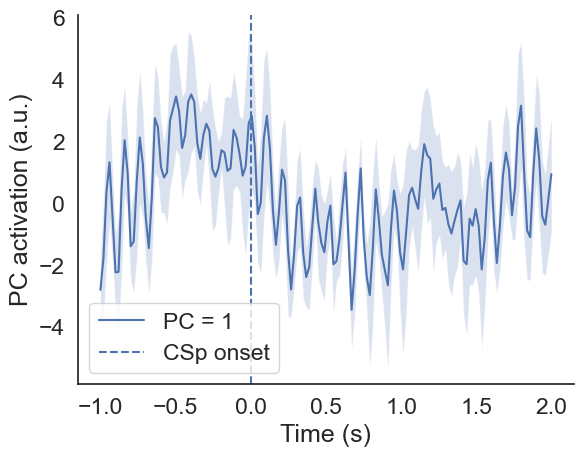

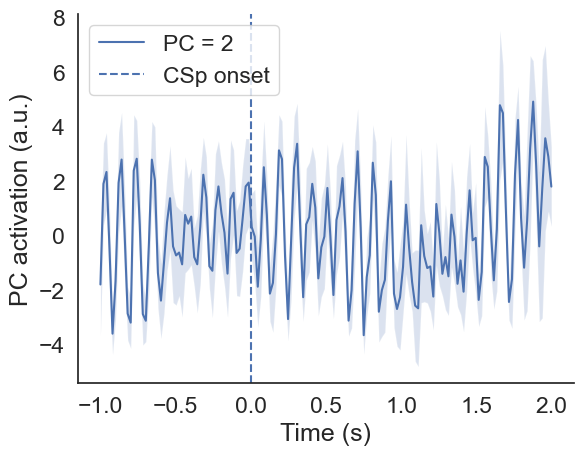

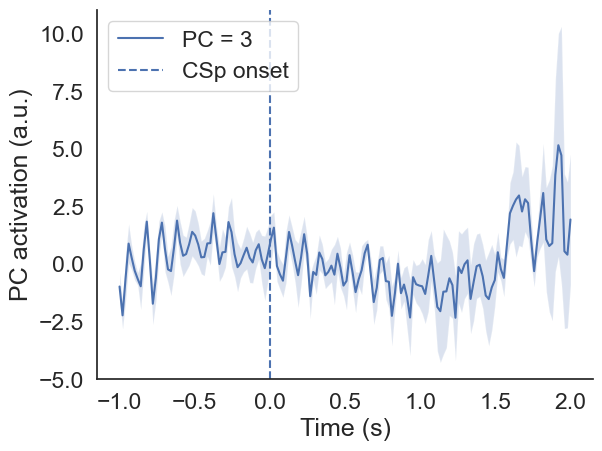

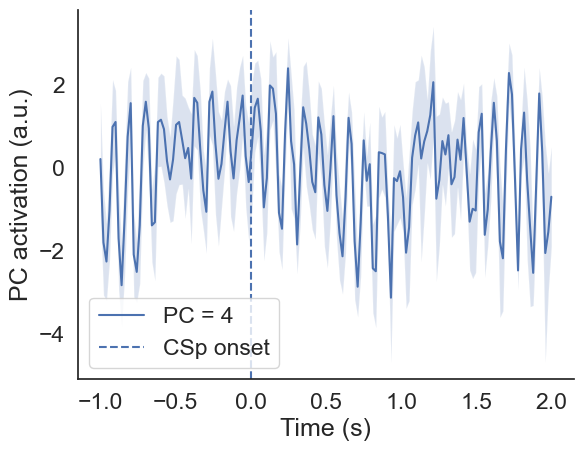

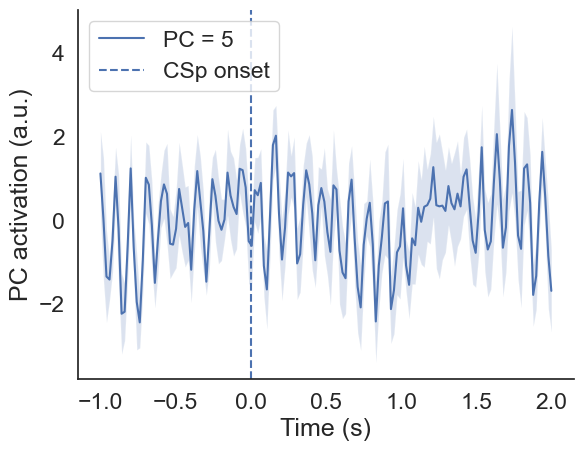

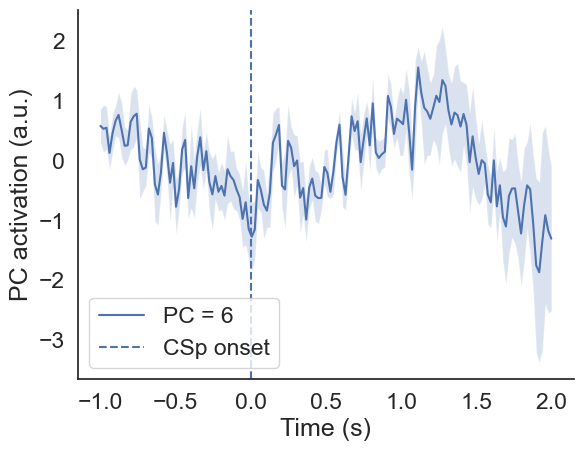

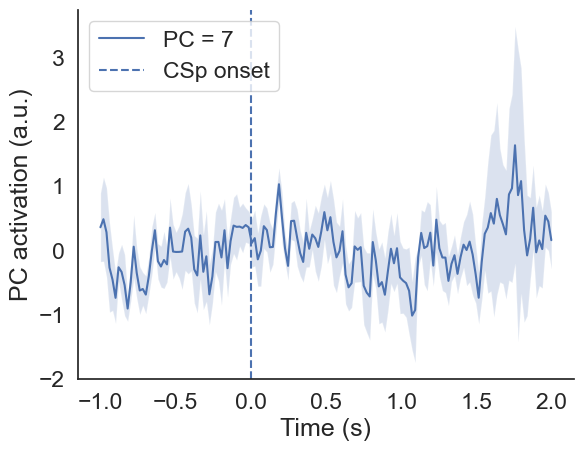

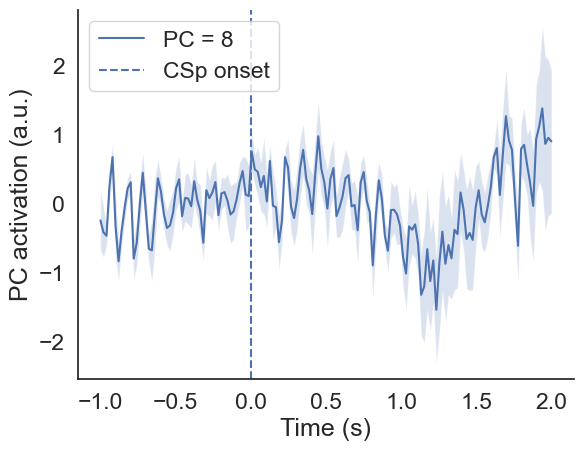

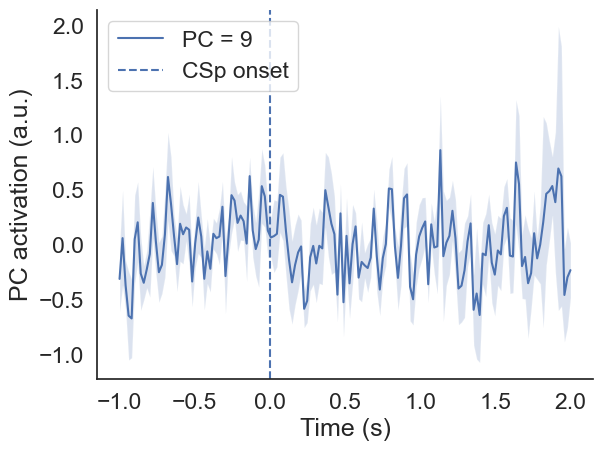

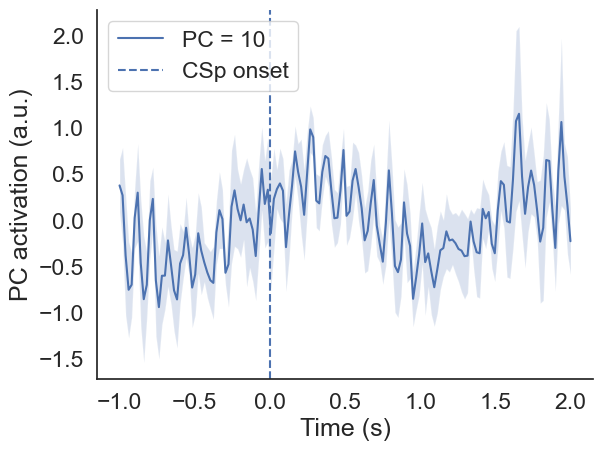

In [159]:
mean_y,err = Opdracht('CSp',3,1)
mean_y,err = Opdracht('CSp',3,2)
mean_y,err = Opdracht('CSp',3,3)
mean_y,err = Opdracht('CSp',3,4)
mean_y,err = Opdracht('CSp',3,5)
mean_y,err = Opdracht('CSp',3,6)
mean_y,err = Opdracht('CSp',3,7)
mean_y,err = Opdracht('CSp',3,8)
mean_y,err = Opdracht('CSp',3,9)
mean_y,err = Opdracht('CSp',3,10)

In [175]:
np.shape(mean_y)[1]

10

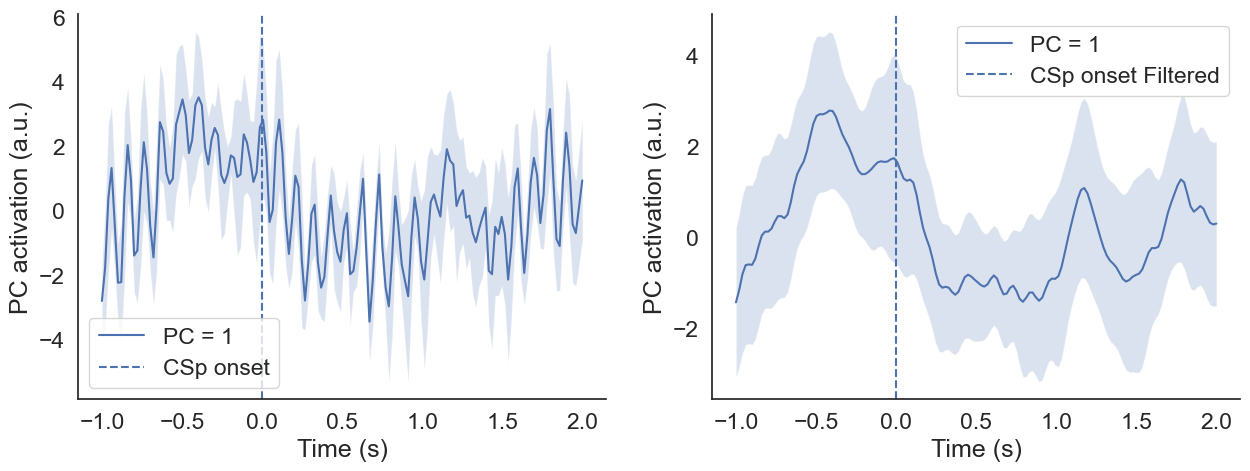

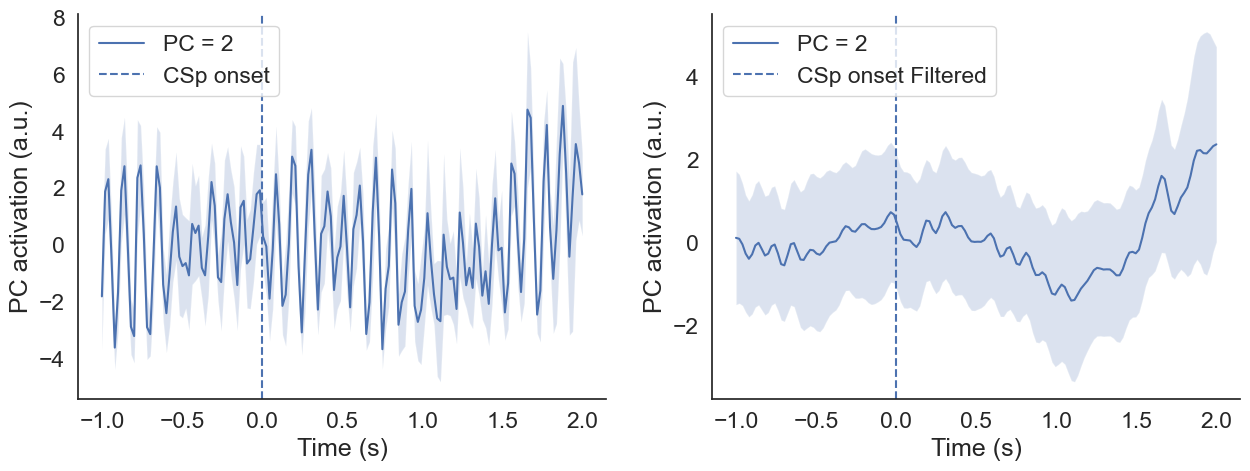

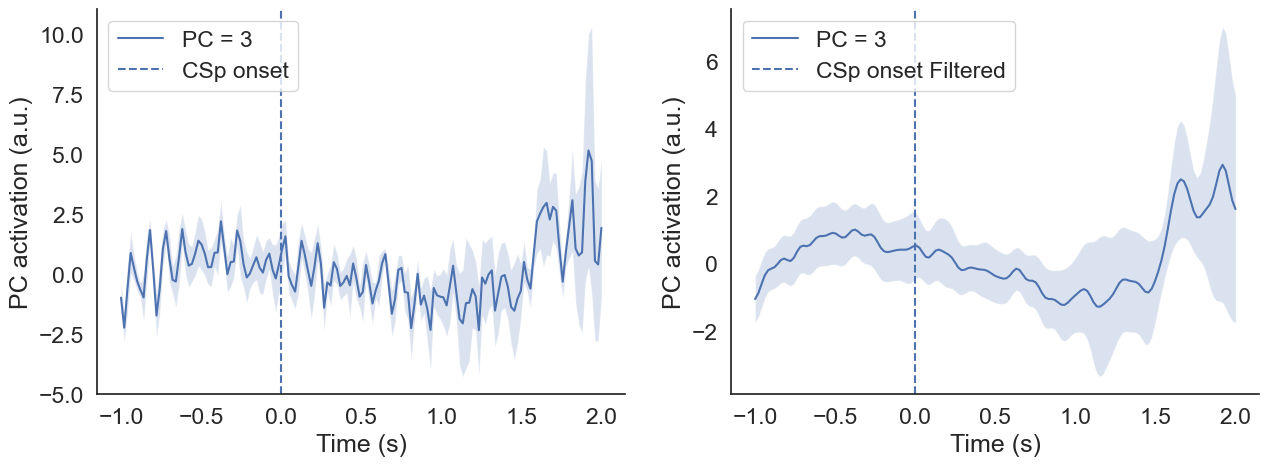

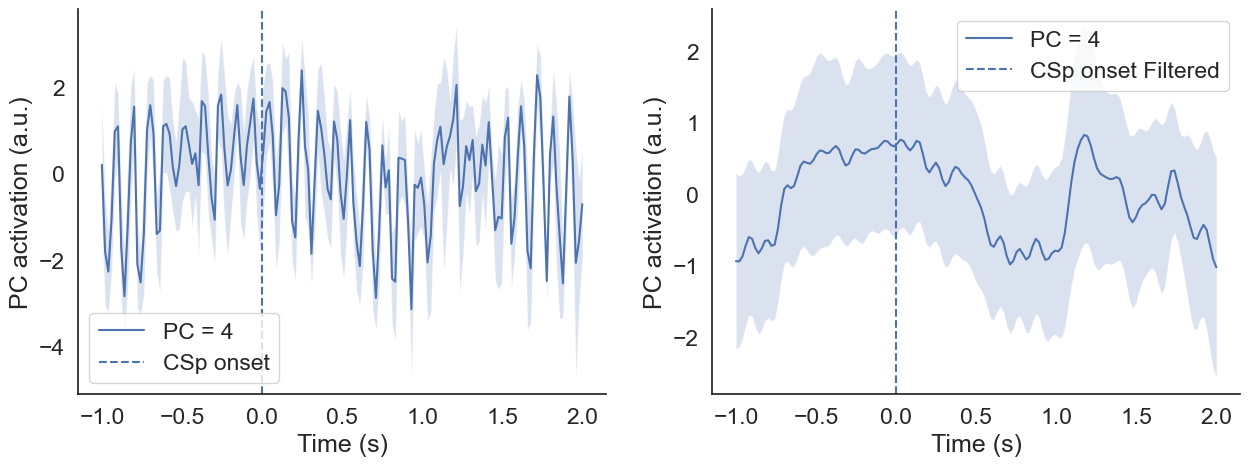

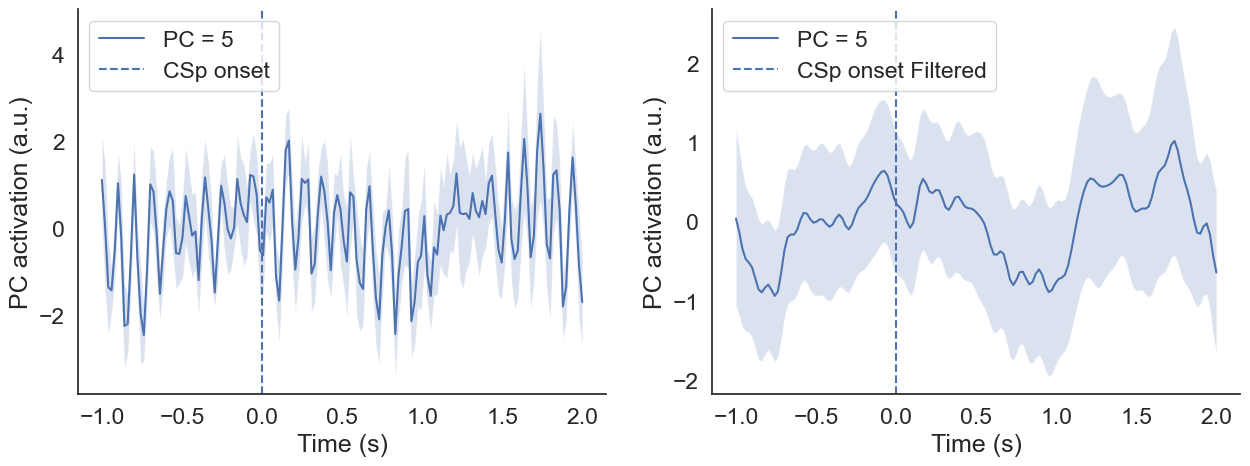

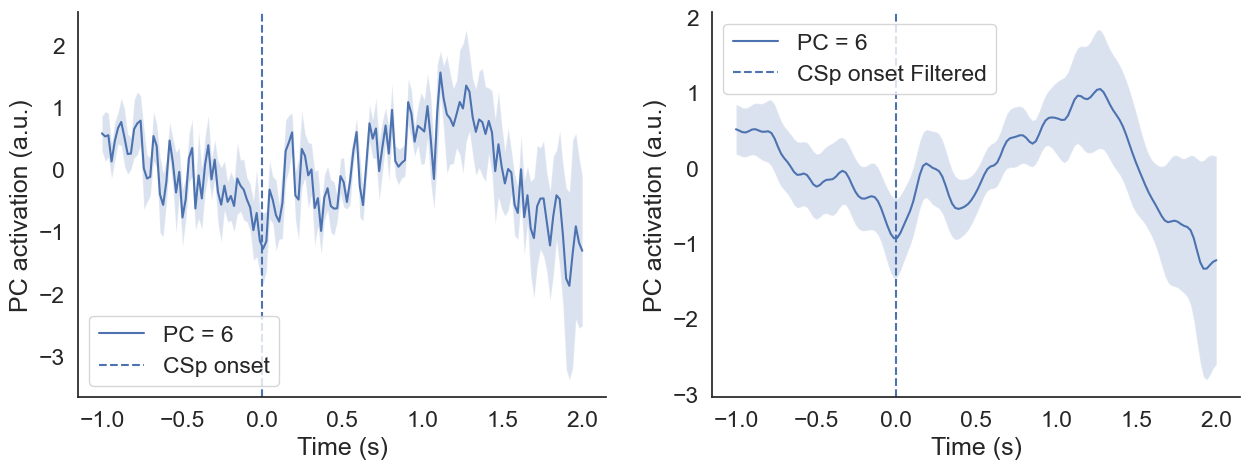

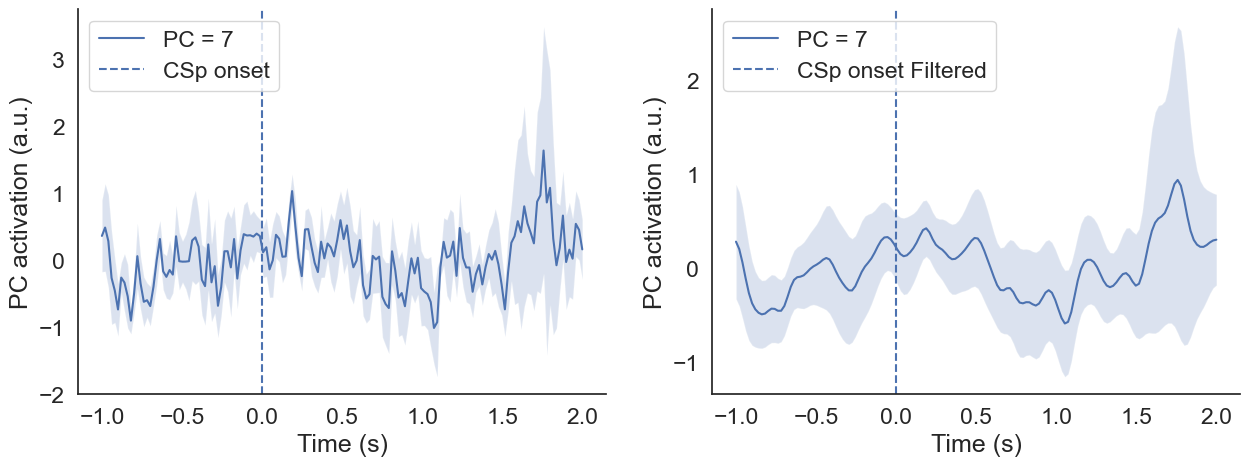

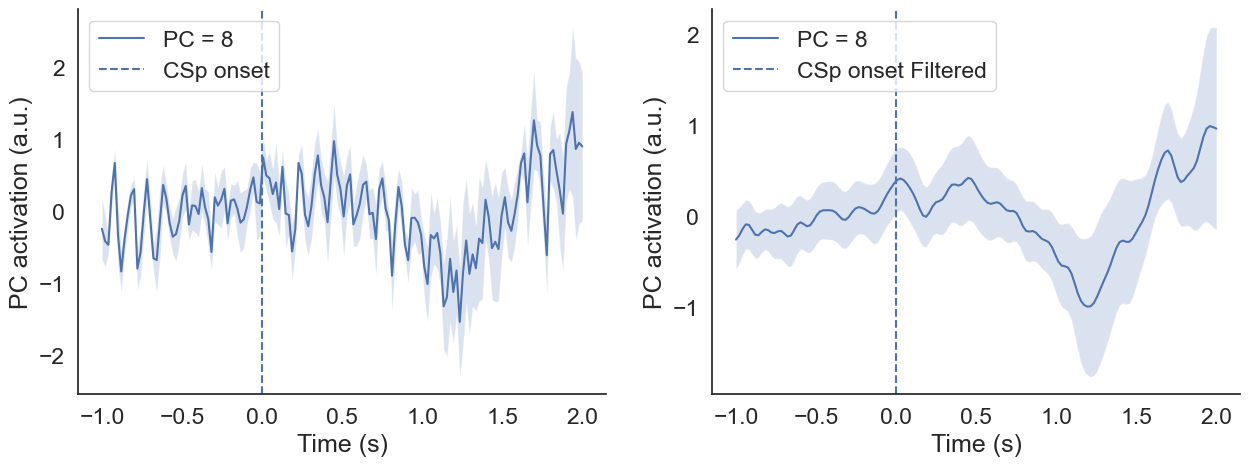

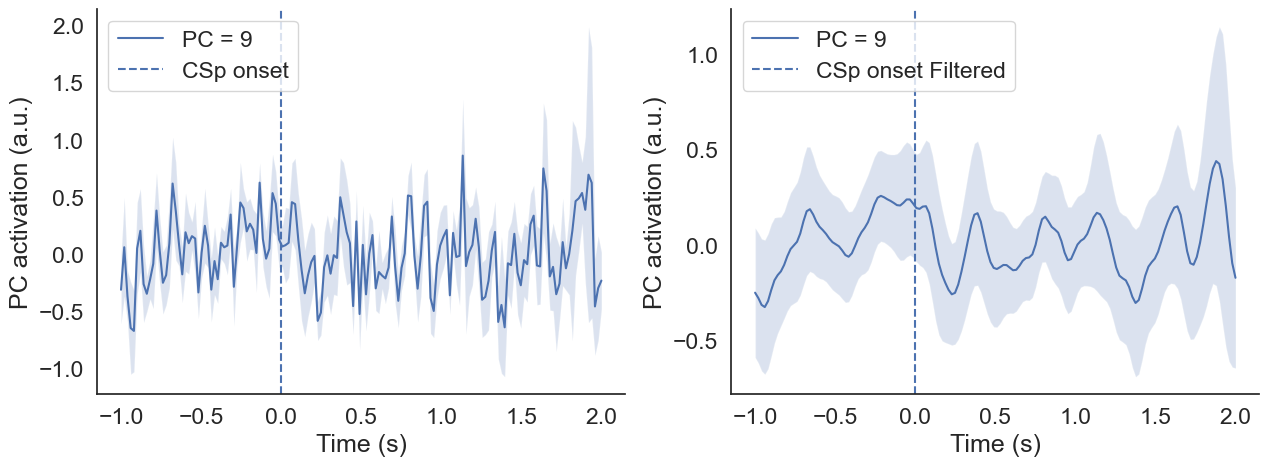

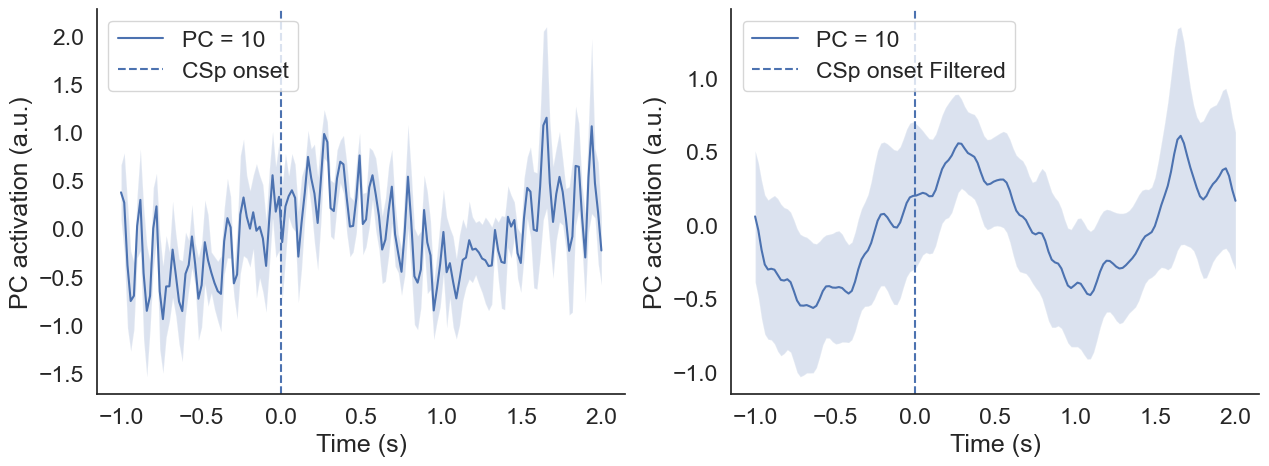

In [181]:
mean_y,err = Opdracht('CSp',3,1,filterr=True,dual=True)
mean_y,err = Opdracht('CSp',3,2,filterr=True,dual=True)
mean_y,err = Opdracht('CSp',3,3,filterr=True,dual=True)
mean_y,err = Opdracht('CSp',3,4,filterr=True,dual=True)
mean_y,err = Opdracht('CSp',3,5,filterr=True,dual=True)
mean_y,err = Opdracht('CSp',3,6,filterr=True,dual=True)
mean_y,err = Opdracht('CSp',3,7,filterr=True,dual=True)
mean_y,err = Opdracht('CSp',3,8,filterr=True,dual=True)
mean_y,err = Opdracht('CSp',3,9,filterr=True,dual=True)
mean_y,err = Opdracht('CSp',3,10,filterr=True,dual=True)

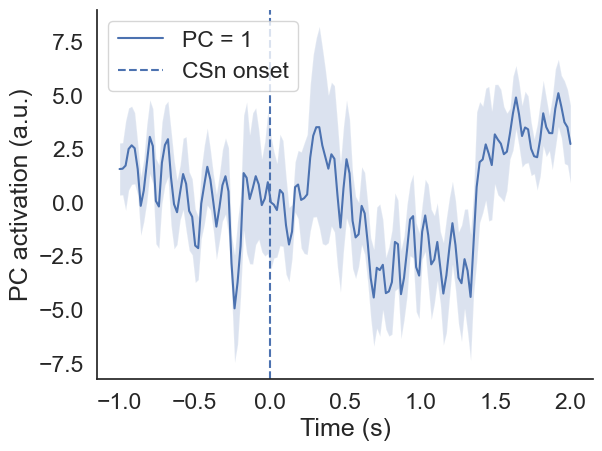

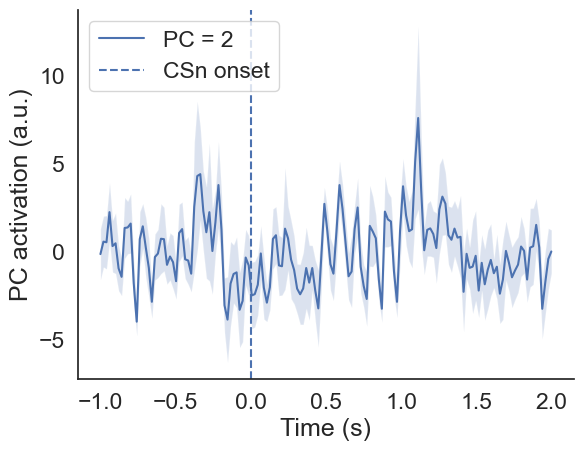

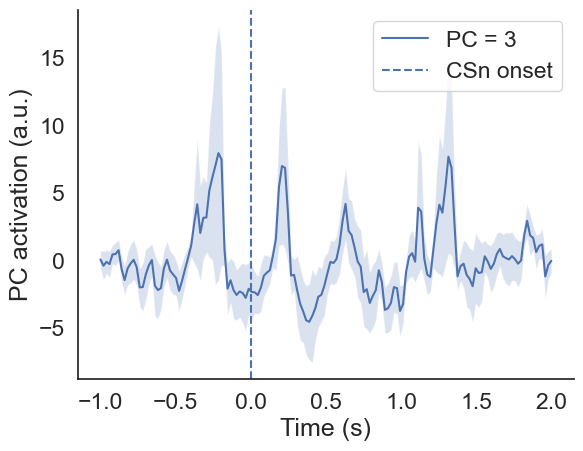

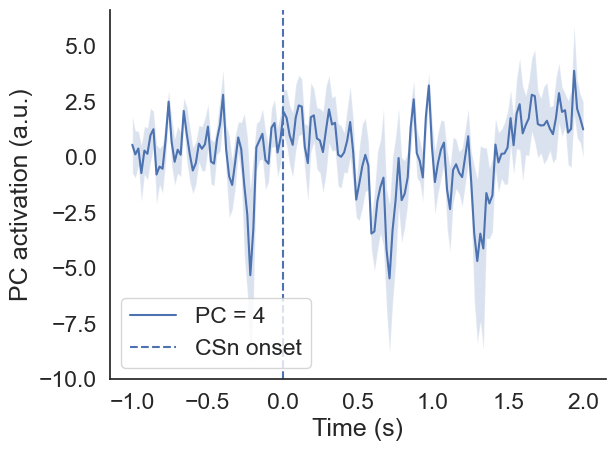

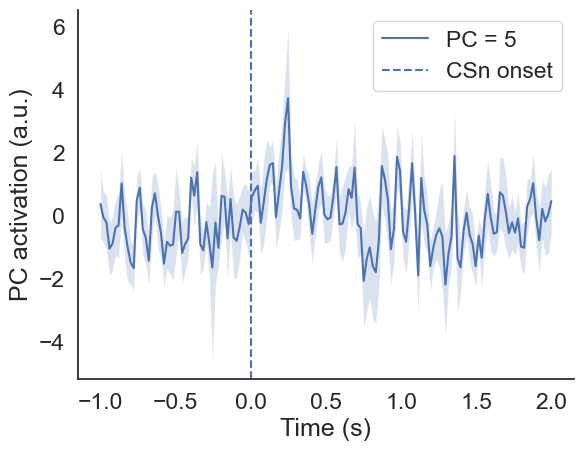

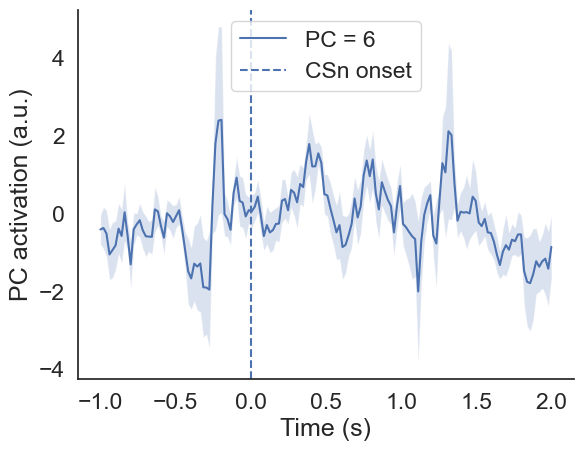

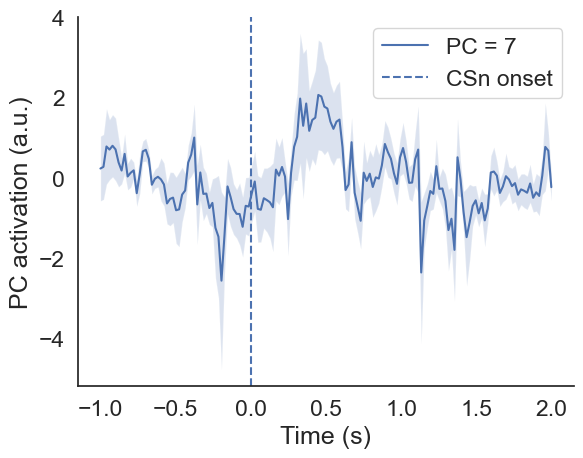

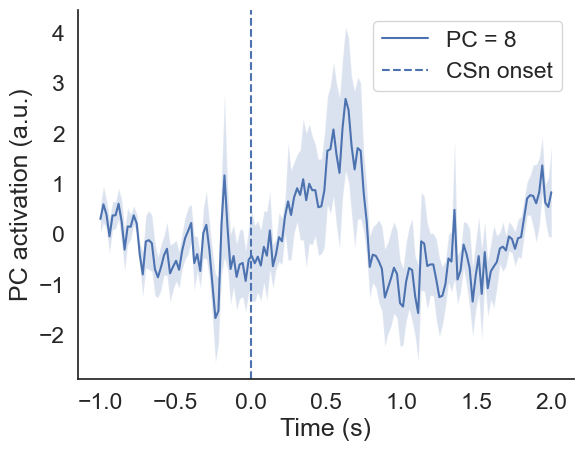

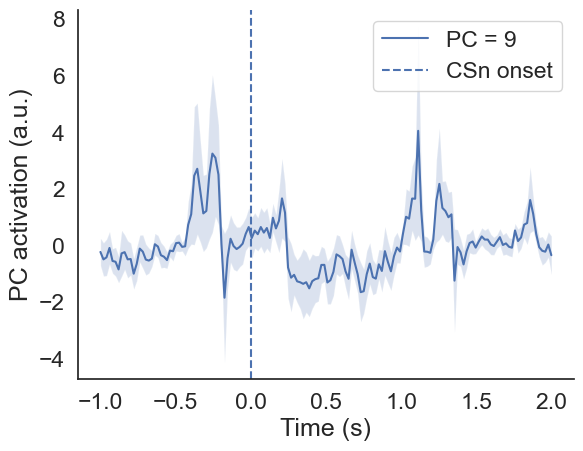

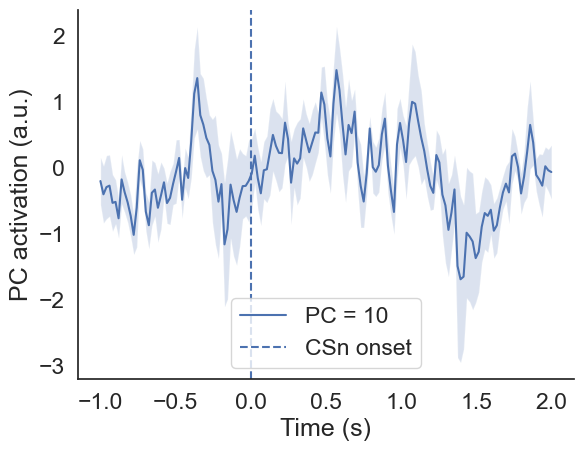

In [162]:
mean_y,err = Opdracht('CSn',3,1)
mean_y,err = Opdracht('CSn',3,2)
mean_y,err = Opdracht('CSn',3,3)
mean_y,err = Opdracht('CSn',3,4)
mean_y,err = Opdracht('CSn',3,5)
mean_y,err = Opdracht('CSn',3,6)
mean_y,err = Opdracht('CSn',3,7)
mean_y,err = Opdracht('CSn',3,8)
mean_y,err = Opdracht('CSn',3,9)
mean_y,err = Opdracht('CSn',3,10)

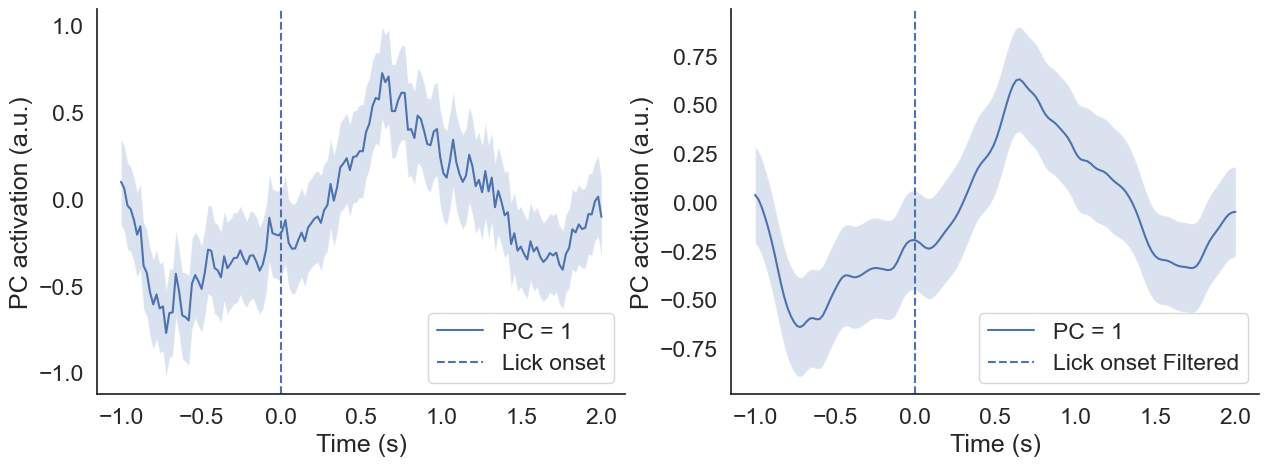

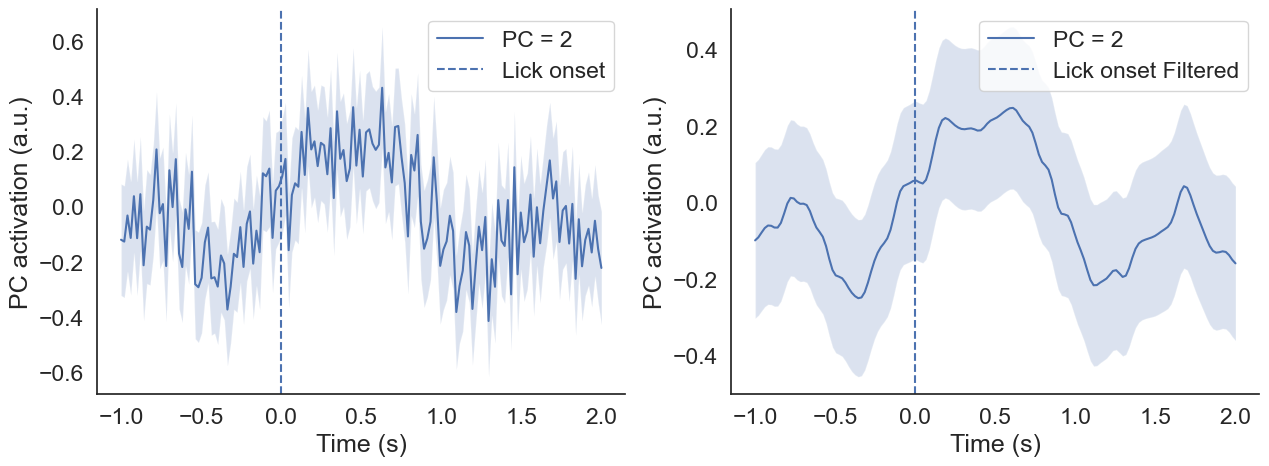

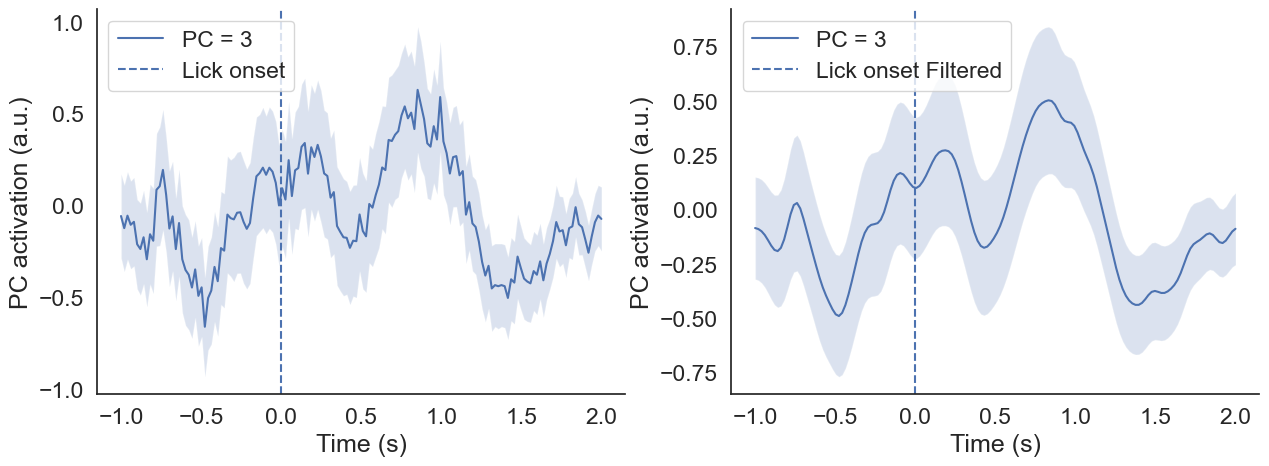

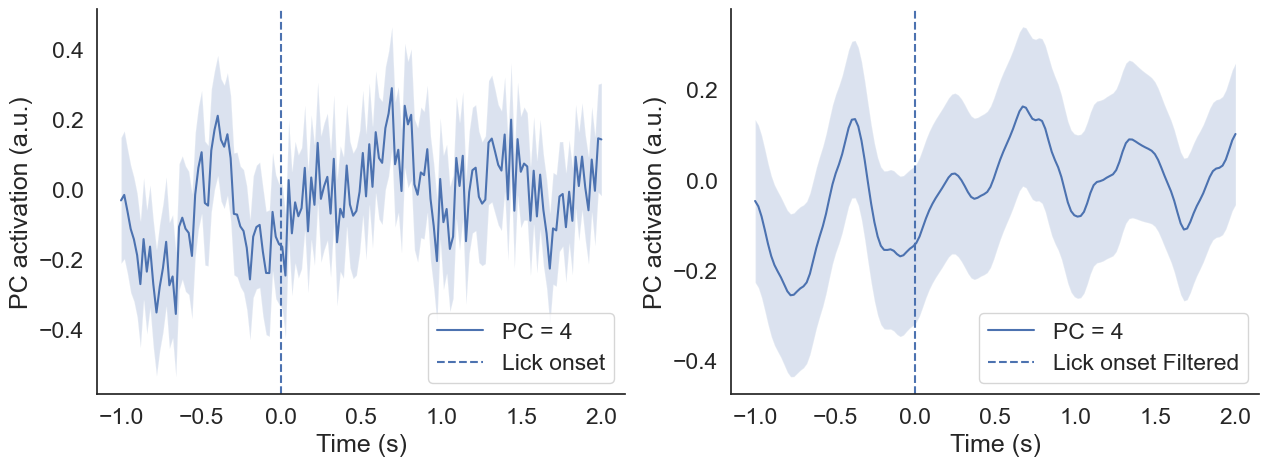

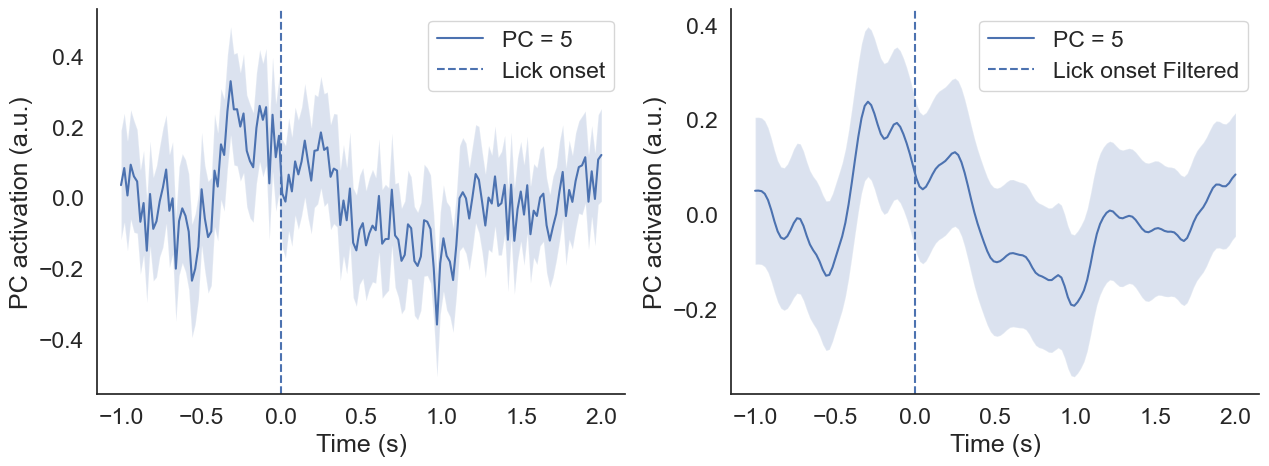

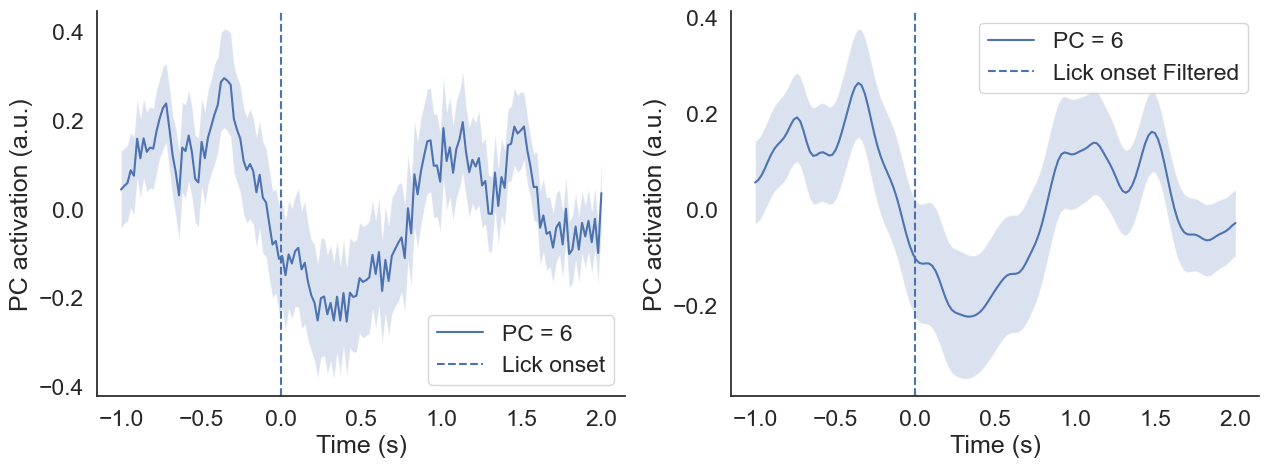

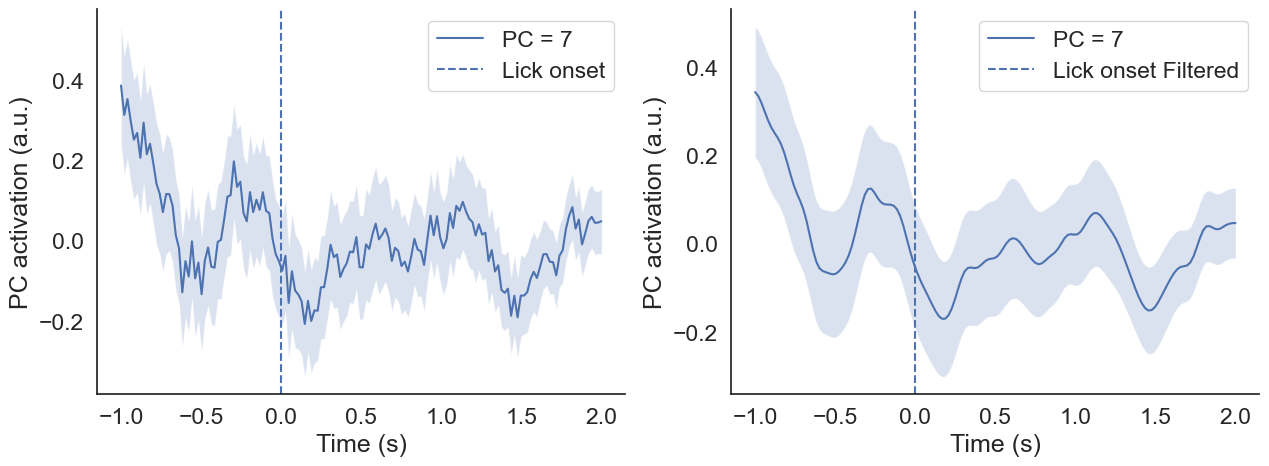

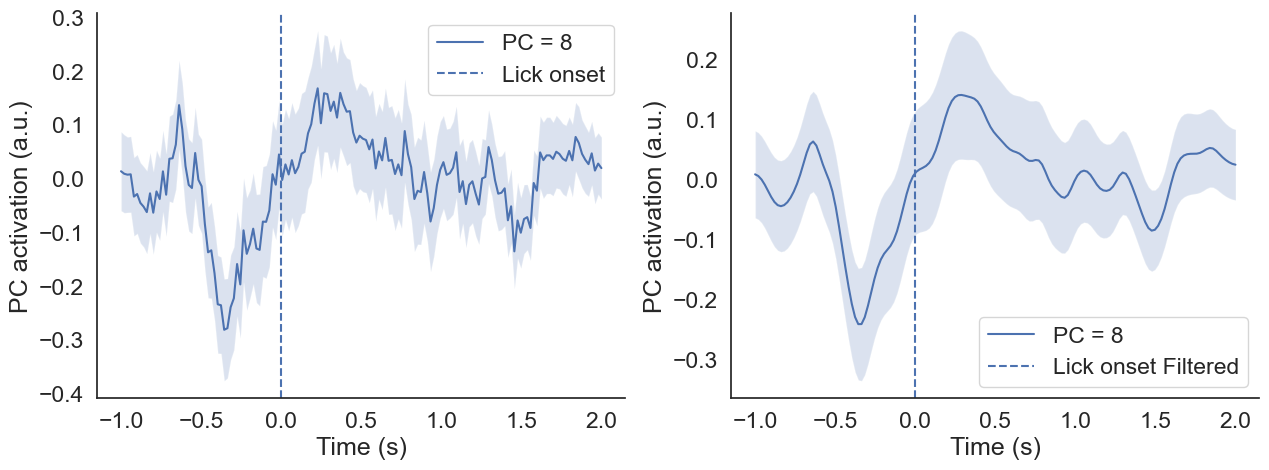

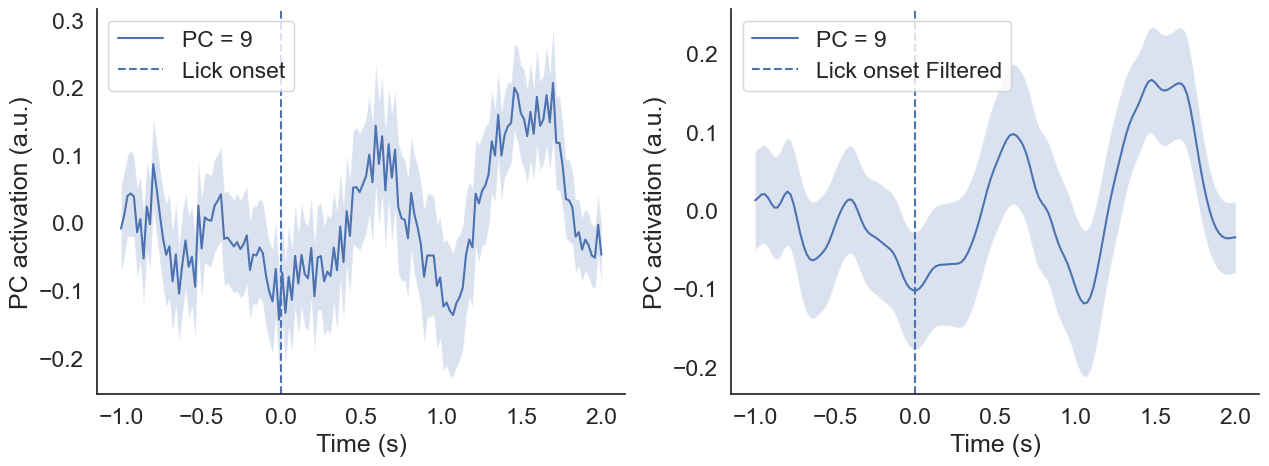

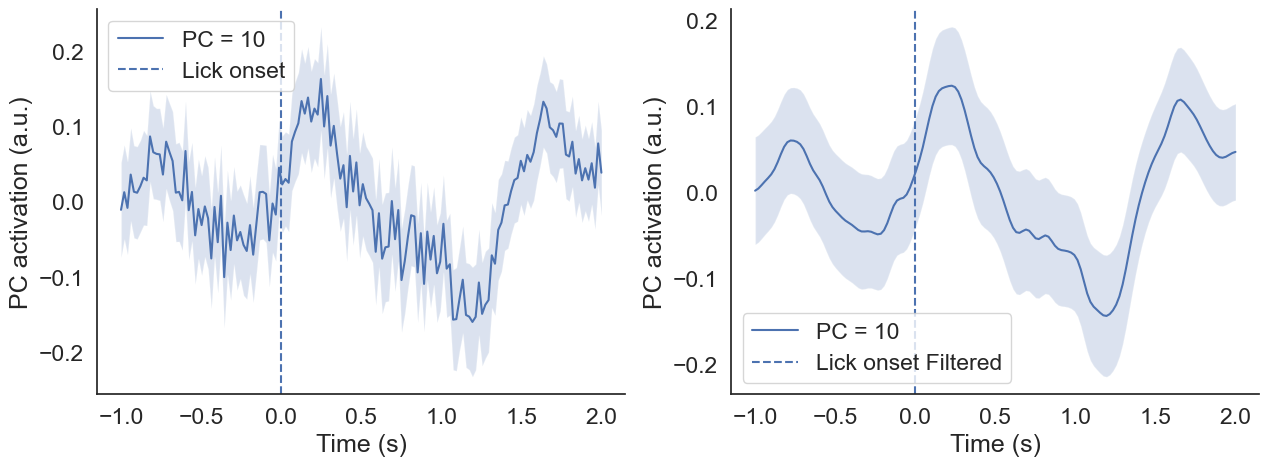

In [182]:
mean_y,err = Opdracht('Lick',3,1,filterr=True,dual=True)
mean_y,err = Opdracht('Lick',3,2,filterr=True,dual=True)
mean_y,err = Opdracht('Lick',3,3,filterr=True,dual=True)
mean_y,err = Opdracht('Lick',3,4,filterr=True,dual=True)
mean_y,err = Opdracht('Lick',3,5,filterr=True,dual=True)
mean_y,err = Opdracht('Lick',3,6,filterr=True,dual=True)
mean_y,err = Opdracht('Lick',3,7,filterr=True,dual=True)
mean_y,err = Opdracht('Lick',3,8,filterr=True,dual=True)
mean_y,err = Opdracht('Lick',3,9,filterr=True,dual=True)
mean_y,err = Opdracht('Lick',3,10,filterr=True,dual=True)

[  280140  1660394  3107174  8821363  9449371  9915868 11197132]
[[-0.01965588  0.00295969  0.02153539 ...  0.03342054  0.04675699
   0.03174026]
 [ 0.04434229  0.05929006  0.0731149  ...  0.01570764  0.03694793
   0.06655653]
 [-0.06059515 -0.07661343 -0.07343684 ... -0.00408192  0.05361128
   0.09148851]
 ...
 [-0.19974743 -0.21874982 -0.21240173 ...  0.12217984  0.13177007
   0.12155521]
 [-0.00335262 -0.00714431  0.02761317 ... -0.10649442 -0.09441284
  -0.08733322]
 [-0.24522513 -0.254815   -0.22177039 ...  0.01984026  0.04603352
   0.07178248]]


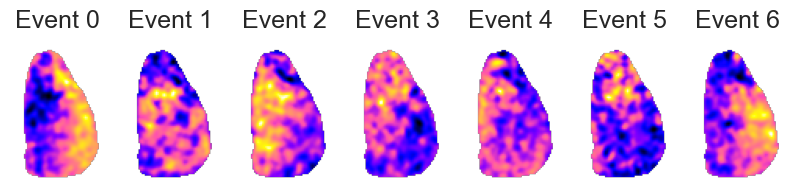

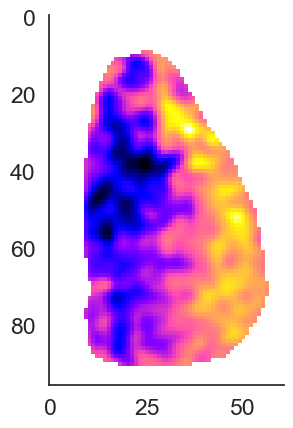

In [161]:
def events(key):
    event_times = trial_data[key]
    event_indices = np.round(np.interp(event_times,Frames,np.arange(len(Frames)))).astype('int')
    return event_indices
    #return np.asarray(event_indices,dtype="int")

events('CSp')
print(Frames[events('CSp')])

def find_onset_time(key):
    indices = events(key)
    return Frames[indices]

event_images = X[events('CSp')]
print(event_images)

fig = plt.figure(figsize=(10,5))
for i,img in enumerate(event_images):
    reshaped = np.full((h,w),np.nan)
    reshaped[np.where(cortex_mask)] = img
    plt.subplot(1,7,i+1)
    plt.title(f'Event {i}')
    plt.imshow(reshaped,cmap=plt.cm.gnuplot2)
    plt.axis('off')
plt.show()
plt.close()

reshaped = np.full((h,w),np.nan)
reshaped[np.where(cortex_mask)] = X[699]
plt.imshow(reshaped,cmap=plt.cm.gnuplot2)

## Exercise 3: nonlinear dimensionality reduction

Using the MNIST digit dataset, explore the effect of hyperparameters on the result of nonlinear dimensionality reduction methods.

- Change the `perplexity` and `exageration` parameters in `TNSE` (one at a time). Graphically compare the results of different values.
- Change the neighbourhood size in `Isomap` (set by the parameter `n_neighbors`), and visualize how the results change.

Finally, try to apply one or more of these methods to the cortical data we used in the lessons. How do the data look in two dimensions? Do any cluster seem to appear? Are they robust with respect to hyperparameter choice?

In [187]:
dataset = load_digits()
images = dataset.data

 # defines a scaler objects
scaler = StandardScaler()
# z-score with fit_transform method
X =scaler.fit_transform(images)

In [209]:
def plot_TSNE(perplexity,early_exaggeration):
    n_comp = 3
    tsne = TSNE(n_components=n_comp,perplexity=perplexity,early_exaggeration=early_exaggeration)
    tsne_results = tsne.fit_transform(X)

    fig = plt.figure(figsize=(15,5))
    plt.subplot(1,3,1)
    plt.scatter(x=tsne_results[:,0],y=tsne_results[:,1],c=dataset.target,label="0,1")
    plt.legend()
    plt.subplot(1,3,2)
    plt.scatter(x=tsne_results[:,0],y=tsne_results[:,2],c=dataset.target,label="0,2")
    plt.legend()
    plt.subplot(1,3,3)
    plt.scatter(x=tsne_results[:,1],y=tsne_results[:,2],c=dataset.target,label="1,2")
    plt.legend()

interact(plot_TSNE, perplexity = widgets.FloatSlider(min=2.,max=100.,value=30.),early_exaggeration = widgets.FloatSlider(min=2.,max=100.,value=12.))


interactive(children=(FloatSlider(value=30.0, description='perplexity', min=2.0), FloatSlider(value=12.0, desc…

<function __main__.plot_TSNE(perplexity, early_exaggeration)>

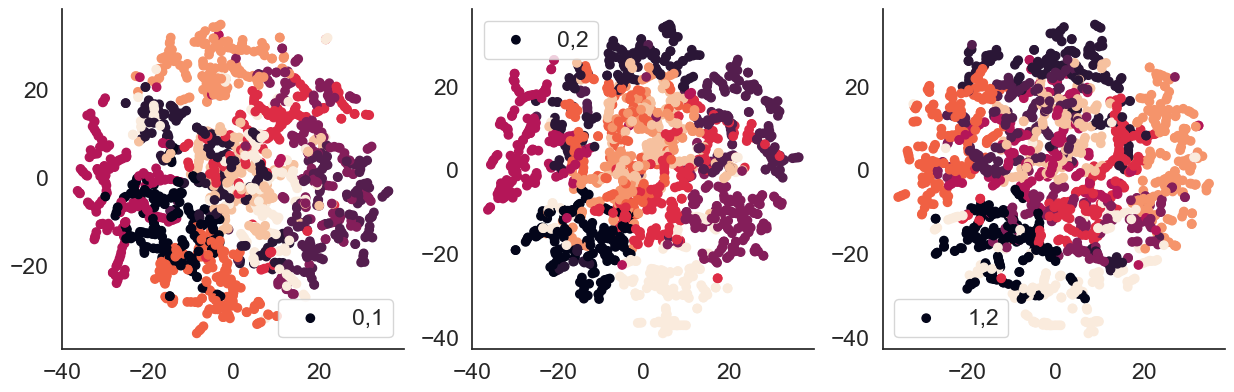

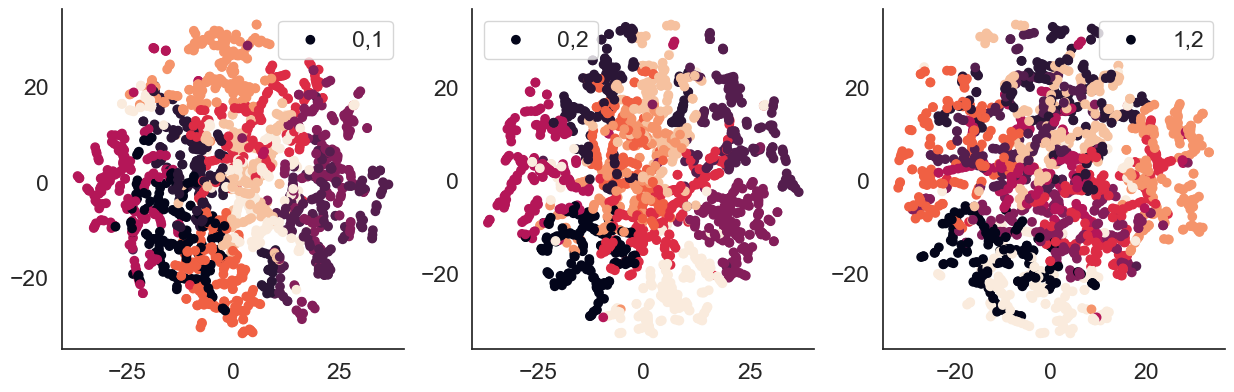

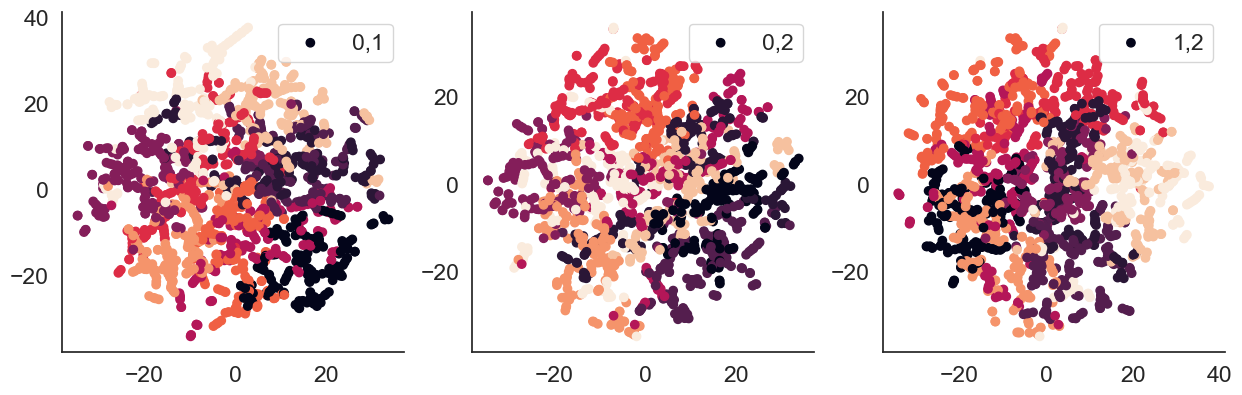

In [212]:
n_comp = 3
perplexity = 2.
early_exaggerations = [2.,12.,50.]

for i in range(3):
    tsne = TSNE(n_components=n_comp,perplexity=perplexity,early_exaggeration=early_exaggerations[i])
    tsne_results = tsne.fit_transform(X)
    
    fig = plt.figure(figsize=(15,15))
    plt.subplot(3,3,3*i+1)
    plt.scatter(x=tsne_results[:,0],y=tsne_results[:,1],c=dataset.target,label="0,1")
    plt.legend()
    plt.subplot(3,3,3*i+2)
    plt.scatter(x=tsne_results[:,0],y=tsne_results[:,2],c=dataset.target,label="0,2")
    plt.legend()
    plt.subplot(3,3,3*i+3)
    plt.scatter(x=tsne_results[:,1],y=tsne_results[:,2],c=dataset.target,label="1,2")
    plt.legend()
plt.show()
plt.close()


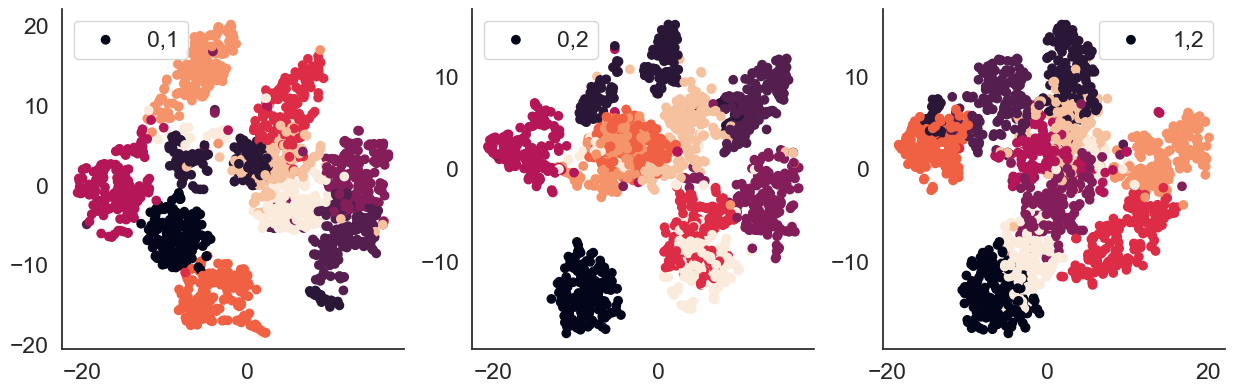

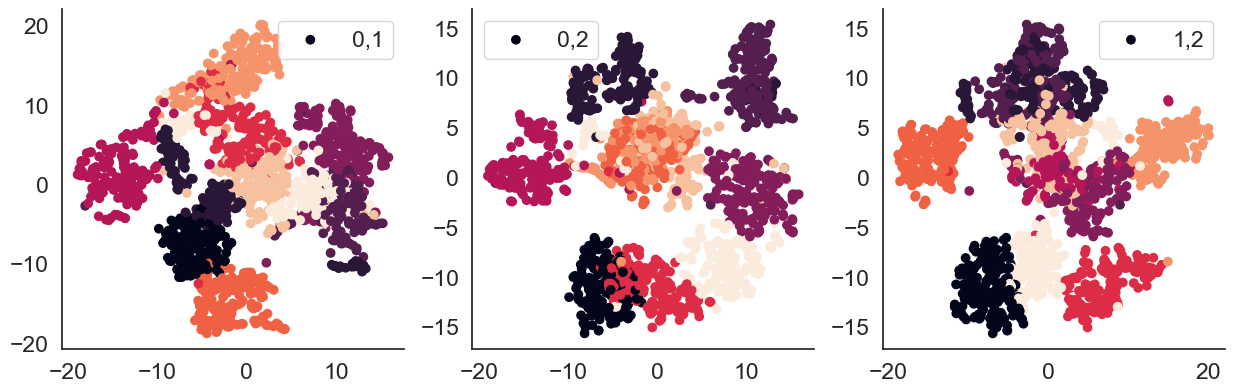

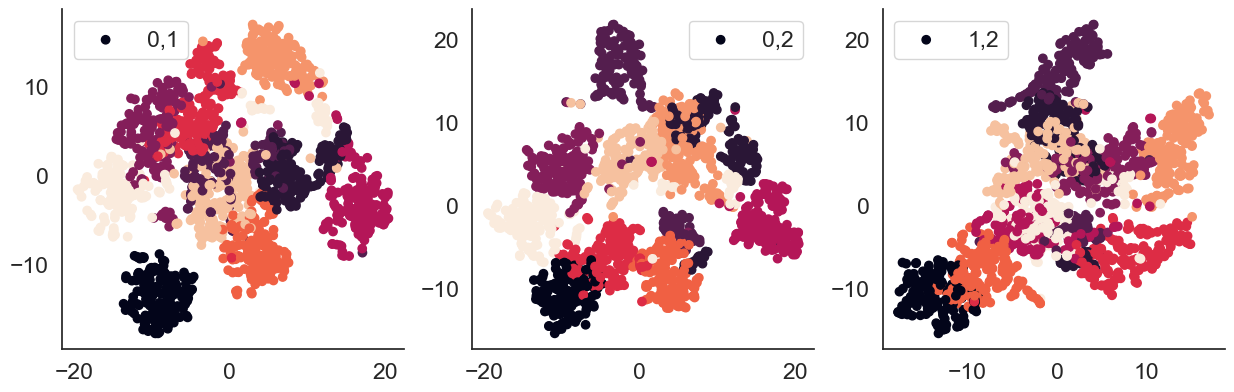

In [211]:
n_comp = 3
perplexity = 30.
early_exaggerations = [2.,12.,50.]

for i in range(3):
    tsne = TSNE(n_components=n_comp,perplexity=perplexity,early_exaggeration=early_exaggerations[i])
    tsne_results = tsne.fit_transform(X)
    
    fig = plt.figure(figsize=(15,15))
    plt.subplot(3,3,3*i+1)
    plt.scatter(x=tsne_results[:,0],y=tsne_results[:,1],c=dataset.target,label="0,1")
    plt.legend()
    plt.subplot(3,3,3*i+2)
    plt.scatter(x=tsne_results[:,0],y=tsne_results[:,2],c=dataset.target,label="0,2")
    plt.legend()
    plt.subplot(3,3,3*i+3)
    plt.scatter(x=tsne_results[:,1],y=tsne_results[:,2],c=dataset.target,label="1,2")
    plt.legend()
plt.show()
plt.close()


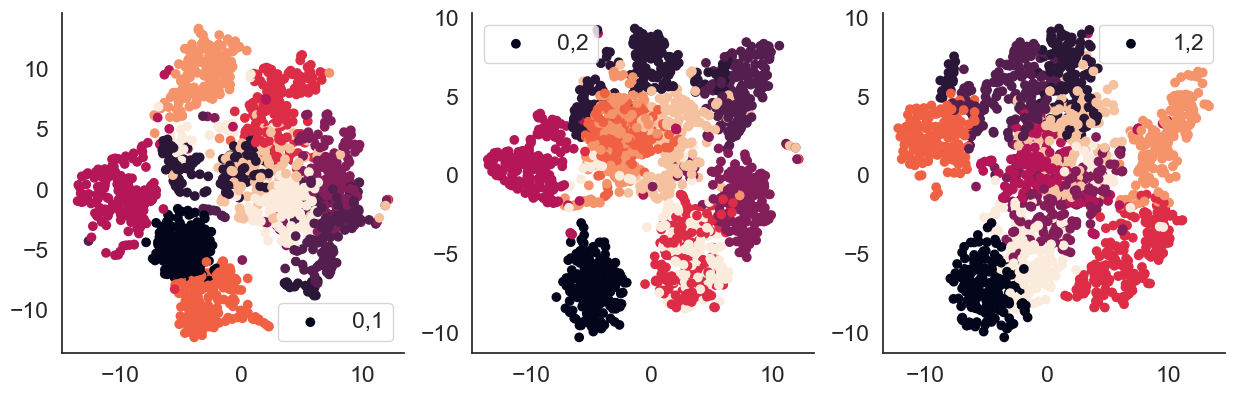

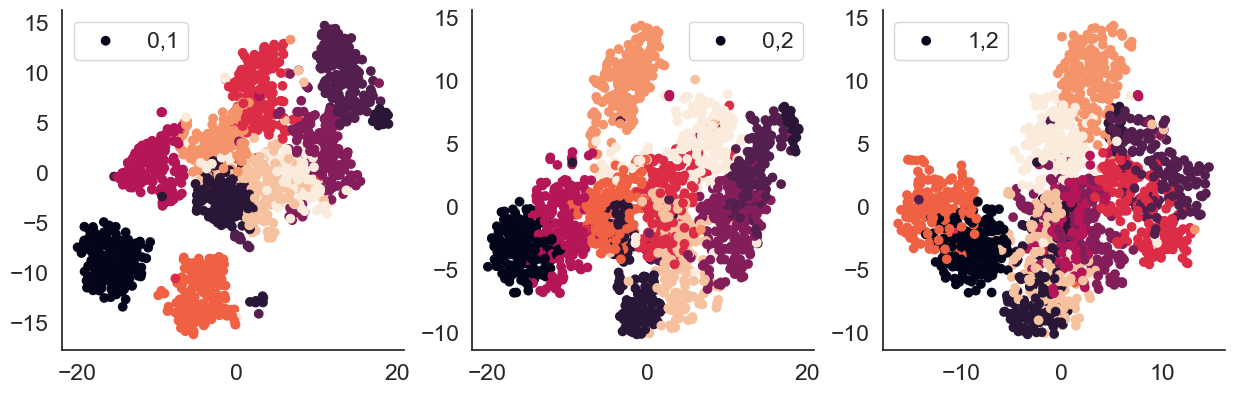

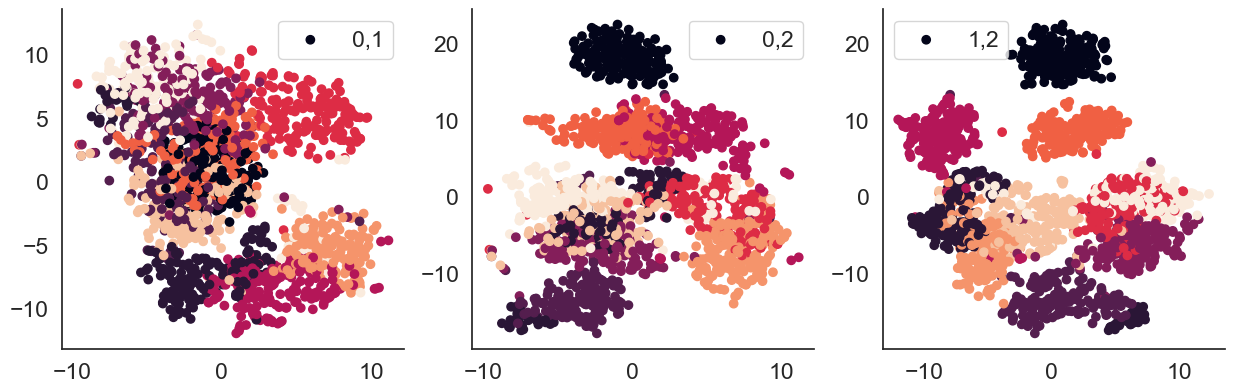

In [213]:
n_comp = 3
perplexity = 100.
early_exaggerations = [2.,12.,50.]

for i in range(3):
    tsne = TSNE(n_components=n_comp,perplexity=perplexity,early_exaggeration=early_exaggerations[i])
    tsne_results = tsne.fit_transform(X)
    
    fig = plt.figure(figsize=(15,15))
    plt.subplot(3,3,3*i+1)
    plt.scatter(x=tsne_results[:,0],y=tsne_results[:,1],c=dataset.target,label="0,1")
    plt.legend()
    plt.subplot(3,3,3*i+2)
    plt.scatter(x=tsne_results[:,0],y=tsne_results[:,2],c=dataset.target,label="0,2")
    plt.legend()
    plt.subplot(3,3,3*i+3)
    plt.scatter(x=tsne_results[:,1],y=tsne_results[:,2],c=dataset.target,label="1,2")
    plt.legend()
plt.show()
plt.close()


The perplexity seems to be forcing the data to cluster. But there also seems to be a point of diminishing returns, as the difference between $2$ and $30$ is far bigger than the difference between $30$ and $100$.

The early_exaggeration seems to push the clusters closer together, alsmost as a balancing force to the perlpexity.

In [220]:
def plot_Isomap(n_neighbors):
    isomap = Isomap(n_components=2,n_neighbors=n_neighbors)
    X_iso = isomap.fit_transform(X)

    plt.scatter(X_iso[:,0],X_iso[:,1],c=dataset.target)
    plt.title('Isomap')
    plt.xlabel('X1')
    plt.ylabel('X2')

interact(plot_Isomap, n_neighbors = widgets.IntSlider(min=2,max=100,value=5))

interactive(children=(IntSlider(value=5, description='n_neighbors', min=2), Output()), _dom_classes=('widget-i…

<function __main__.plot_Isomap(n_neighbors)>

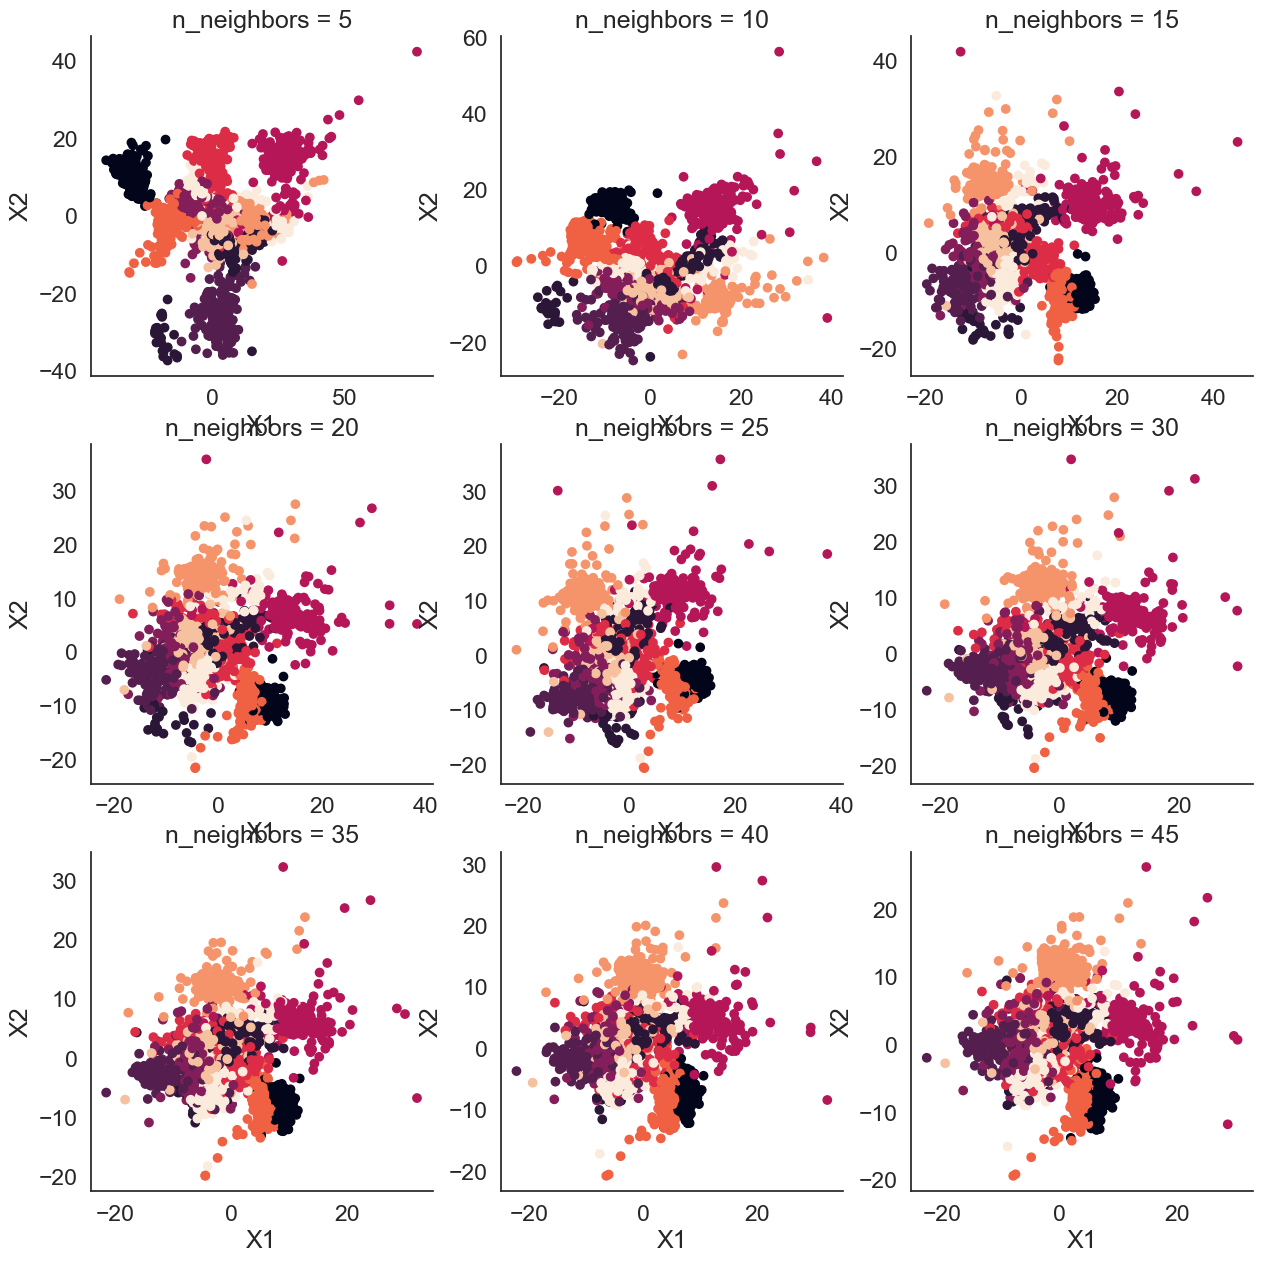

In [224]:
n_neighborss = np.array([5,10,15,20,25,30,35,40,45])

fig = plt.figure(figsize=(15,15))
for i,n_neighbors in enumerate(n_neighborss):
    isomap = Isomap(n_components=2,n_neighbors=n_neighbors)
    X_iso = isomap.fit_transform(X)

    plt.subplot(3,3,i+1)
    plt.scatter(X_iso[:,0],X_iso[:,1],c=dataset.target)
    plt.title(f'n_neighbors = {n_neighbors}')
    plt.xlabel('X1')
    plt.ylabel('X2')
plt.show()
plt.close()

The number of neighbours seems to be forcing the clusters together as it increases, which seems to make some intuitive sence, but contrary to what my first guess would have been.